In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest



In [5]:
SEED = 42
OUT = Path("/kaggle/working/task12_results")
OUT.mkdir(exist_ok=True)

df = pd.read_csv(
    "/kaggle/input/datasets/mczielinski/bitcoin-historical-data/btcusd_1-min_data.csv",
    usecols=["Timestamp", "Open", "High", "Low", "Close", "Volume"],
    dtype={c: "float32" for c in ["Open", "High", "Low", "Close", "Volume"]}
)

df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s", utc=True)
df = df.set_index("Timestamp").resample("1h").agg({
    "Open": "first", "High": "max", "Low": "min",
    "Close": "last", "Volume": "sum"
})

In [6]:
log_close = np.log(df["Close"])
data = pd.DataFrame(index=df.index)
data["return_1h"] = log_close.diff()
data["return_24h"] = log_close.diff(24)
data["return_168h"] = log_close.diff(168)
data["volatility_24h"] = data["return_1h"].rolling(24).std()
data["volatility_168h"] = data["return_1h"].rolling(168).std()
data["range"] = (df["High"] - df["Low"]) / df["Open"]
data["log_volume"] = np.log1p(df["Volume"])
data["volume_change"] = data["log_volume"].diff(24)
data["target"] = log_close.shift(-24) - log_close
data = data.replace([np.inf, -np.inf], np.nan).dropna()

X = data.drop(columns="target").astype("float32")
y = data["target"].astype("float32")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [06:08:06] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


mae                rmse                  r2  \
                              mean       std      mean       std      mean   
protocol      split                                                          
chronological test        0.024395  0.006021  0.036015  0.009227 -0.109263   
              train       0.023032  0.001427  0.034283  0.002322  0.560681   
              validation  0.024460  0.008159  0.036453  0.011696 -0.113575   
random        test        0.023489  0.000177  0.036740  0.000639  0.226868   
              train       0.022373  0.000076  0.033335  0.000119  0.360386   
              validation  0.023511  0.000197  0.036324  0.000676  0.222301   

                                   direction_accuracy            
                               std               mean       std  
protocol      split                                              
chronological test        0.086204           0.506647  0.017511  
              train       0.158256           0.647280  0.046403  
              validation  0.105821           0.501958  0.012395  
random        test        0.027481           0.563145  0.001344  
              train       0.011642           0.583071  0.003304  
              validation  0.028603           0.561253  0.004285

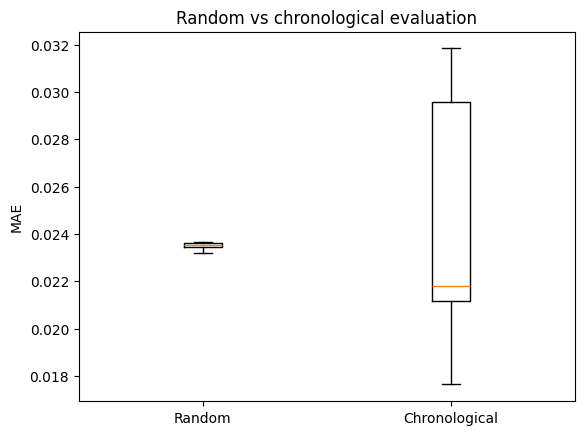

,condition,mae,rmse,r2,direction_accuracy
0,clean,0.017281,0.023956,-0.022171,0.491742
1,volume_missing,0.019526,0.026145,-0.217493,0.502129


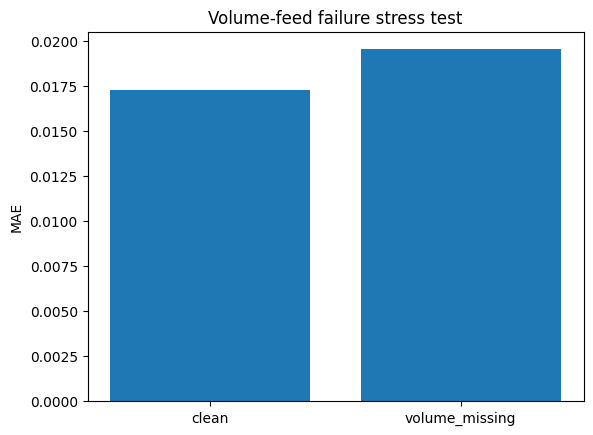

,return_1h,volatility_24h,range,log_volume
cluster,,,,
0,-0.006978,0.034501,0.064250,6.714265
1,0.000032,0.004675,0.004684,3.566491
2,0.000373,0.007895,0.013089,5.843087


,contamination,roc_auc,detected_rate
0,0.005,0.997948,0.000042
1,0.010,0.997948,0.000083
2,0.020,0.997948,0.000458


Saved results to /kaggle/working/task12_results


In [7]:
def new_model(seed):
    return XGBRegressor(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        device="cuda",
        random_state=seed
    )

def metrics(actual, predicted):
    return {
        "mae": mean_absolute_error(actual, predicted),
        "rmse": np.sqrt(mean_squared_error(actual, predicted)),
        "r2": r2_score(actual, predicted),
        "direction_accuracy": np.mean((actual > 0) == (predicted > 0))
    }

results = []

def evaluate(protocol, run, train, validation, test, seed):
    model = new_model(seed)
    model.fit(X.iloc[train], y.iloc[train])

    for name, indices in [
        ("train", train), ("validation", validation), ("test", test)
    ]:
        results.append({
            "protocol": protocol,
            "run": run,
            "split": name,
            **metrics(y.iloc[indices], model.predict(X.iloc[indices]))
        })

indices = np.arange(len(X))

for run, seed in enumerate([11, 22, 33, 44, 55], 1):
    train, remaining = train_test_split(
        indices, test_size=0.30, random_state=seed
    )
    validation, test = train_test_split(
        remaining, test_size=0.50, random_state=seed
    )
    evaluate("random", run, train, validation, test, seed)

tscv = TimeSeriesSplit(n_splits=5, gap=24)

for run, (train_validation, test) in enumerate(tscv.split(X), 1):
    split = int(len(train_validation) * 0.85)
    train = train_validation[:split - 24]
    validation = train_validation[split:]
    evaluate("chronological", run, train, validation, test, SEED + run)

results = pd.DataFrame(results)
summary = results.groupby(["protocol", "split"])[
    ["mae", "rmse", "r2", "direction_accuracy"]
].agg(["mean", "std"])

display(summary)
results.to_csv(OUT / "evaluation_results.csv", index=False)
summary.to_csv(OUT / "evaluation_summary.csv")

test_results = results[results["split"] == "test"]
plt.boxplot(
    [test_results[test_results["protocol"] == p]["mae"]
     for p in ["random", "chronological"]],
    tick_labels=["Random", "Chronological"]
)
plt.ylabel("MAE")
plt.title("Random vs chronological evaluation")
plt.savefig(OUT / "split_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

split = int(len(X) * 0.85)
train = np.arange(split - 24)
test = np.arange(split, len(X))

final_model = new_model(SEED)
final_model.fit(X.iloc[train], y.iloc[train])

clean_prediction = final_model.predict(X.iloc[test])
stressed_X = X.iloc[test].copy()
stressed_X[["log_volume", "volume_change"]] = np.nan
stressed_prediction = final_model.predict(stressed_X)

stress_results = pd.DataFrame([
    {"condition": "clean", **metrics(y.iloc[test], clean_prediction)},
    {"condition": "volume_missing", **metrics(y.iloc[test], stressed_prediction)}
])

display(stress_results)
stress_results.to_csv(OUT / "stress_test.csv", index=False)

plt.bar(stress_results["condition"], stress_results["mae"])
plt.ylabel("MAE")
plt.title("Volume-feed failure stress test")
plt.savefig(OUT / "stress_test.png", dpi=150, bbox_inches="tight")
plt.show()

predictions = pd.DataFrame({
    "actual": y.iloc[test],
    "clean_prediction": clean_prediction,
    "stressed_prediction": stressed_prediction
}, index=X.iloc[test].index)

predictions["absolute_error"] = abs(
    predictions["actual"] - predictions["clean_prediction"]
)
predictions.to_csv(OUT / "test_predictions.csv")

monthly_errors = predictions["absolute_error"].resample("MS").mean()
monthly_errors.to_csv(OUT / "monthly_errors.csv")

unsupervised_columns = [
    "return_1h", "volatility_24h", "range", "log_volume"
]

sample = X[unsupervised_columns].sample(
    min(80000, len(X)), random_state=SEED
).sort_index()

scaler = StandardScaler()
scaled = scaler.fit_transform(sample)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=SEED)
sample["cluster"] = kmeans.fit_predict(scaled)

cluster_summary = sample.groupby("cluster").mean()
display(cluster_summary)
cluster_summary.to_csv(OUT / "cluster_summary.csv")

split = int(len(sample) * 0.70)
anomaly_scaler = StandardScaler()
anomaly_train = anomaly_scaler.fit_transform(
    sample.iloc[:split][unsupervised_columns]
)
anomaly_test = anomaly_scaler.transform(
    sample.iloc[split:][unsupervised_columns]
)

anomaly_results = []

for contamination in [0.005, 0.01, 0.02]:
    detector = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=SEED,
        n_jobs=-1
    )
    detector.fit(anomaly_train)

    score = -detector.decision_function(anomaly_test)
    actual_anomaly = (
        sample.iloc[split:]["return_1h"].abs()
        >= sample.iloc[split:]["return_1h"].abs().quantile(0.99)
    ).astype(int)

    anomaly_results.append({
        "contamination": contamination,
        "roc_auc": roc_auc_score(actual_anomaly, score),
        "detected_rate": np.mean(detector.predict(anomaly_test) == -1)
    })

    if contamination == 0.01:
        joblib.dump(
            (anomaly_scaler, detector),
            OUT / "isolation_forest.joblib"
        )

anomaly_results = pd.DataFrame(anomaly_results)
display(anomaly_results)
anomaly_results.to_csv(OUT / "anomaly_results.csv", index=False)

final_model.save_model(OUT / "bitcoin_model.json")
joblib.dump((scaler, kmeans), OUT / "kmeans.joblib")

print(f"Saved results to {OUT}")